R2 Score: 0.8652305915031616
Predicted Medical Charges: 19072.665976499993


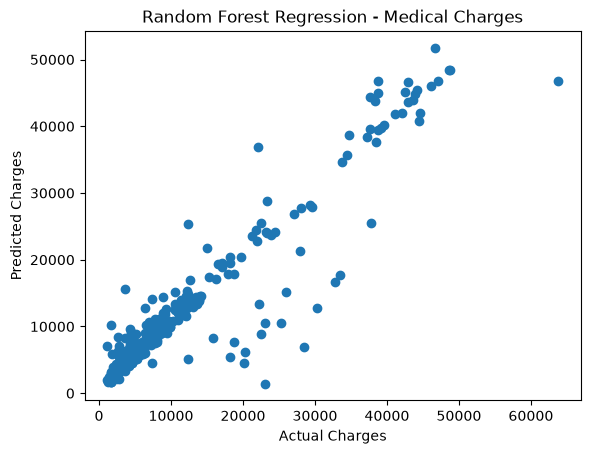

In [1]:
# 9. Predicting Medical Charges using Random Forest
# Dataset: Medical Cost Personal Datasets

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("Medical_cost.csv")

# Convert categorical columns into numerical columns
df = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

# Independent variables
X = df.drop('charges', axis=1)

# Target variable
y = df['charges']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Random Forest model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# R2 Score
print("R2 Score:", r2_score(y_test, y_pred))

# New person prediction
new_person = pd.DataFrame([{
    'age': 30,
    'bmi': 25.5,
    'children': 1,
    'sex_male': 1,
    'smoker_yes': 1,
    'region_northwest': 0,
    'region_southeast': 0,
    'region_southwest': 0
}])

# Make sure columns are in the same order as training data
new_person = new_person[X.columns]

print(
    "Predicted Medical Charges:",
    model.predict(new_person)[0]
)

# Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Random Forest Regression - Medical Charges")
plt.show()